<a href="https://colab.research.google.com/github/qtbun0w0/My-first-Repo/blob/main/try_rdkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
pip install rdkit

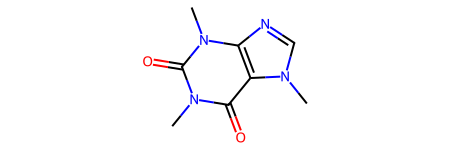

In [7]:
from rdkit import Chem
m = Chem.MolFromSmiles('CN1C=NC2=C1C(=O)N(C(=O)N2C)C')

m

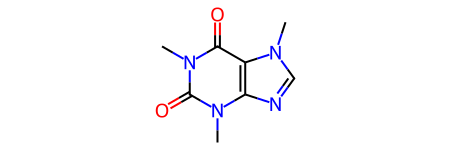

In [8]:
import requests
caffeine_url = 'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/CID/2519/record/SDF?record_type=2d&response_type=display$0'
caffeine_mol = requests.get(caffeine_url).text
caffeine = Chem.MolFromMolBlock(caffeine_mol)
caffeine


In [17]:
caffeine.GetNumAtoms() # แต่ไม่ได้นับ H atom ด้วยนะ

14

In [24]:
[atom.GetSymbol() for atom in caffeine.GetAtoms()]

['O', 'O', 'N', 'N', 'N', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']

In [26]:
[atom.GetSymbol() for atom in caffeine.GetAtoms() if not atom.IsInRing()]

['O', 'O', 'C', 'C', 'C']

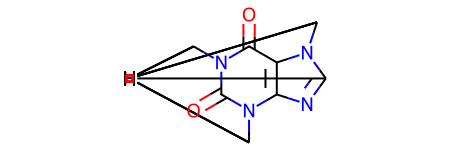

In [27]:
caffeine_with_H = Chem.AddHs(caffeine)
caffeine_with_H # อันนี้ H ไม่ได้มี coordinates ตอน add เข้ามา

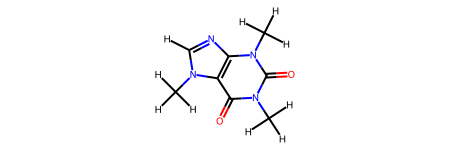

In [29]:
from rdkit.Chem import AllChem
AllChem.Compute2DCoords(caffeine_with_H)
caffeine_with_H

In [37]:
from rdkit.Chem import Descriptors
print(Descriptors.ExactMolWt(caffeine))
print(Descriptors.ExactMolWt(caffeine_with_H))
print(Descriptors.MolWt(caffeine_with_H))
print(Descriptors.NumRotatableBonds(caffeine)) # สามารถดึง Lipinski's Rule of five มาใช้เล่นได้เลยย อิอิ

194.08037556
194.08037556
194.19400000000007
0
